In [1]:
#Ссылка на датасет: https://www.kaggle.com/datasets/samiraalipour/gene-expression-omnibus-geo-dataset-gse68086?select=GSE68086_TEP_data_matrix.csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
#Закружаем наш файл .csv
df = pd.read_csv('GSE68086_TEP_data_matrix.csv/GSE68086_TEP_data_matrix.csv', low_memory= False)

# Устанавливаем названия генов как ИНДЕКС
df = df.set_index('Unnamed: 0')
#Транспонируем матрицу для удобства (чтобы пациенты были в виде строк, а гены в виде колонок)
df_ml = df.T

#Убираем ненужные гены, в которых уровень экспрессии везде равен нулю
df_ml = df_ml.loc[:, (df_ml!=0).any(axis = 0)]

##Нам нужно отобрать 500 самых информативных генов
# 1. отбираем 500 генов с наивысшей дисперсией, что указывает на их важность в определении рака
df_500genes = df_ml.var().sort_values(ascending= False).head(500).index
# 2. создаем новую таблицу с этими 500 генами
df_gen = df_ml[df_500genes].copy()

##Нам еще нужно создать новую колонку, в которой будет написан диагноз пациента, так как сейчас у каждого индивидуальный
def extract_target(sample_id):
    name = sample_id.upper()
    # Сначала ищем здоровых (Healthy Donors и Controls)
    if 'HD-' in name or 'CONTROL' in name:
        return 'Healthy'
    
    # Затем классифицируем виды рака по ключевым словам из твоего списка
    if 'BREAST' in name or 'BRCA' in name:
        return 'Breast Cancer'
    elif 'LUNG' in name or 'NSCLC' in name:
        return 'Lung Cancer'
    elif 'CRC' in name:
        return 'Colorectal Cancer'
    elif 'GBM' in name:
        return 'Glioblastoma'
    elif 'LIVER' in name or 'CHOL' in name:
        return 'Liver/Bile Cancer'
    elif 'PANC' in name:
        return 'Pancreatic Cancer'

    else:
        return 'Unknown/Other'

#Выводим первые 5 строк
display(df_gen.head())

#по очериде берем каждый индекс из колоник с диагнозом пациента и передаем нашей функции; создаем новую колонку куда вписываем все ответы  
df_gen['target'] = df_gen.index.map(extract_target)
#смотрим сколько людей с каким диагнозом у нас есть
print("Распределение пациентов по группам:")
print(df_gen['target'].value_counts())

Unnamed: 0,ENSG00000166710,ENSG00000163736,ENSG00000244734,ENSG00000205542,ENSG00000075624,ENSG00000124491,ENSG00000120885,ENSG00000113140,ENSG00000087086,ENSG00000142669,...,ENSG00000138758,ENSG00000103187,ENSG00000148498,ENSG00000111229,ENSG00000142937,ENSG00000160255,ENSG00000182093,ENSG00000131051,ENSG00000180628,ENSG00000150867
3-Breast-Her2-ampl,455636,174575,9196,170603,98215,126323,79147,49463,49795,27736,...,1153,74,952,1274,633,403,1363,1128,1223,470
8-Breast-WT,252687,287079,11383,55688,58139,136380,79130,70562,49950,20473,...,1742,48,1608,831,151,104,2077,1078,766,776
10-Breast-Her2-ampl,289755,198153,2307,74621,60400,94795,88665,57545,66387,40552,...,1056,90,1188,665,151,27,749,1007,909,439
Breast-100,102324,56275,1045,81024,19337,20058,13329,11896,9707,7385,...,372,19,396,270,204,26,157,282,281,177
15-Breast-Her2-ampl,274821,210277,7681,90779,85098,86390,59012,35986,42894,29858,...,556,115,892,664,125,34,1104,501,703,413


Распределение пациентов по группам:
target
Lung Cancer          59
Healthy              54
Colorectal Cancer    44
Breast Cancer        38
Glioblastoma         38
Pancreatic Cancer    33
Liver/Bile Cancer    12
Unknown/Other         7
Name: count, dtype: int64


In [2]:
# --- ПУНКТ A: БЫСТРЫЙ ОБЗОР ДАННЫХ ---

# Размерность
print(f"СТРУКТУРА: В датасете {df_gen.shape[0]} пациентов и {df_gen.shape[1]} признаков (500 генов + target).")
# Выведем первые и последние 5 строчек
display(df_gen.head())
display(df_gen.tail())
# Общаяя информация
df_gen.info() 
# Основная статистика для наших генов (числовые данные)
display(df_gen.describe().iloc[:, :10])
# Статистика для пациентов (строковые данные)
display(df_gen.describe(include= 'object'))

#Проверка качества: Типы данных и дубликаты
display(f'Колличество дубликатов: {df_gen.duplicated().sum()}')
display(f'Колличество нулевых строк: {df_gen.isnull().sum().sum()}')

СТРУКТУРА: В датасете 285 пациентов и 501 признаков (500 генов + target).


Unnamed: 0,ENSG00000166710,ENSG00000163736,ENSG00000244734,ENSG00000205542,ENSG00000075624,ENSG00000124491,ENSG00000120885,ENSG00000113140,ENSG00000087086,ENSG00000142669,...,ENSG00000103187,ENSG00000148498,ENSG00000111229,ENSG00000142937,ENSG00000160255,ENSG00000182093,ENSG00000131051,ENSG00000180628,ENSG00000150867,target
3-Breast-Her2-ampl,455636,174575,9196,170603,98215,126323,79147,49463,49795,27736,...,74,952,1274,633,403,1363,1128,1223,470,Breast Cancer
8-Breast-WT,252687,287079,11383,55688,58139,136380,79130,70562,49950,20473,...,48,1608,831,151,104,2077,1078,766,776,Breast Cancer
10-Breast-Her2-ampl,289755,198153,2307,74621,60400,94795,88665,57545,66387,40552,...,90,1188,665,151,27,749,1007,909,439,Breast Cancer
Breast-100,102324,56275,1045,81024,19337,20058,13329,11896,9707,7385,...,19,396,270,204,26,157,282,281,177,Breast Cancer
15-Breast-Her2-ampl,274821,210277,7681,90779,85098,86390,59012,35986,42894,29858,...,115,892,664,125,34,1104,501,703,413,Breast Cancer


Unnamed: 0,ENSG00000166710,ENSG00000163736,ENSG00000244734,ENSG00000205542,ENSG00000075624,ENSG00000124491,ENSG00000120885,ENSG00000113140,ENSG00000087086,ENSG00000142669,...,ENSG00000103187,ENSG00000148498,ENSG00000111229,ENSG00000142937,ENSG00000160255,ENSG00000182093,ENSG00000131051,ENSG00000180628,ENSG00000150867,target
MGH-NSCLC-L40-TR520,95842,48093,536,67112,23500,24291,15785,12828,19442,9846,...,649,398,160,90,3,413,360,602,709,Lung Cancer
MGH-NSCLC-L51-TR521,132807,118205,1552,66138,76296,34175,39204,30626,30362,22663,...,1725,505,459,151,70,477,197,1108,946,Lung Cancer
MGH-NSCLC-L58-TR525,144572,97309,11649,67813,71006,22364,45961,48494,33979,19586,...,1422,884,562,219,51,438,639,1537,2055,Lung Cancer
MGH-NSCLC-L59-TR522,102096,38416,385,53070,40251,18949,11525,9884,19031,5051,...,1073,312,375,275,51,209,101,991,440,Lung Cancer
MGH-NSCLC-L65-TR523,141051,152978,663,72446,85981,51798,45896,43635,36166,23225,...,2667,838,687,43,4,1149,395,1457,1098,Lung Cancer


<class 'pandas.core.frame.DataFrame'>
Index: 285 entries, 3-Breast-Her2-ampl to MGH-NSCLC-L65-TR523
Columns: 501 entries, ENSG00000166710 to target
dtypes: int64(500), object(1)
memory usage: 1.1+ MB


Unnamed: 0,ENSG00000166710,ENSG00000163736,ENSG00000244734,ENSG00000205542,ENSG00000075624,ENSG00000124491,ENSG00000120885,ENSG00000113140,ENSG00000087086,ENSG00000142669
count,285.000000,285.000000,2.850000e+02,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000
mean,165408.649123,116148.638596,1.280675e+04,83675.161404,56610.361404,38981.961404,37399.575439,28910.824561,27990.831579,19204.852632
std,98669.377061,81741.545096,6.422271e+04,48419.308735,41077.571379,32883.912106,24716.049146,18343.623158,17225.843695,13785.964369
min,13150.000000,7185.000000,3.000000e+01,8197.000000,2210.000000,128.000000,2045.000000,1009.000000,3338.000000,1688.000000
25%,91784.000000,58159.000000,1.690000e+03,50889.000000,28428.000000,12201.000000,18823.000000,15485.000000,14967.000000,9556.000000
50%,142455.000000,98583.000000,4.160000e+03,74051.000000,51563.000000,29981.000000,34152.000000,27491.000000,25698.000000,16931.000000
75%,231196.000000,153986.000000,8.149000e+03,103601.000000,73747.000000,59296.000000,50386.000000,39353.000000,38222.000000,25396.000000
max,469738.000000,593937.000000,1.047567e+06,360542.000000,377751.000000,152312.000000,191287.000000,105628.000000,92265.000000,101289.000000


Unnamed: 0,target
count,285
unique,8
top,Lung Cancer
freq,59


'Колличество дубликатов: 0'

'Колличество нулевых строк: 0'

In [3]:
# --- ПУНКТ B: ПРОПУСКИ И ОЧИСТКА ---
# у меня пропусков нету, поэтому будет лишь демострация как это должно работать; создаем копию для работы
df_demo = df_gen.copy()
# Выберем гены для примера, у которых мы уберем какие-либо значения
example_gene1 = df_demo.columns[0]
example_gene2 = df_demo.columns[1]
example_patient1 = df_demo.index[0]

df_demo.loc[example_patient1 , df_demo.columns[0:2]] = np.nan
# Проверка работы fillna (mean)
df_demo[example_gene1] = df_demo[example_gene1].fillna(df_demo[example_gene1].mean())
df_demo[example_gene1] = df_demo[example_gene1].astype(int)
# Проверка работы fillna (median)
df_demo[example_gene2] = df_demo[example_gene2].fillna(df_demo[example_gene1].median())
df_demo[example_gene2] = df_demo[example_gene2].astype(int)
display(df_demo.head(10))

#Moda
#сначала выставим одно значение Na для наглядности
df_demo.loc[example_patient1 , 'target'] = np.nan
# считаем моду для 'target'
Moda = df_demo['target'].mode()[0]
print(Moda)

## проверка работы dropna
#создаем копию нашего проекта
df_clean = df_demo.copy()
#для наглядности удаляем превую строчку нашей таблицы
df_clean.iloc[0, :] = np.nan
#удаляем строки, в которых колличество ненулевых строк больше 250
df_clean = df_clean.dropna(axis = 0, thresh = 250)

cols = df_clean.columns[:-1]
df_clean[cols] = df_clean[cols].astype(int)
display(df_clean)

Unnamed: 0,ENSG00000166710,ENSG00000163736,ENSG00000244734,ENSG00000205542,ENSG00000075624,ENSG00000124491,ENSG00000120885,ENSG00000113140,ENSG00000087086,ENSG00000142669,...,ENSG00000103187,ENSG00000148498,ENSG00000111229,ENSG00000142937,ENSG00000160255,ENSG00000182093,ENSG00000131051,ENSG00000180628,ENSG00000150867,target
3-Breast-Her2-ampl,164386,142455,9196,170603,98215,126323,79147,49463,49795,27736,...,74,952,1274,633,403,1363,1128,1223,470,Breast Cancer
8-Breast-WT,252687,287079,11383,55688,58139,136380,79130,70562,49950,20473,...,48,1608,831,151,104,2077,1078,766,776,Breast Cancer
10-Breast-Her2-ampl,289755,198153,2307,74621,60400,94795,88665,57545,66387,40552,...,90,1188,665,151,27,749,1007,909,439,Breast Cancer
Breast-100,102324,56275,1045,81024,19337,20058,13329,11896,9707,7385,...,19,396,270,204,26,157,282,281,177,Breast Cancer
15-Breast-Her2-ampl,274821,210277,7681,90779,85098,86390,59012,35986,42894,29858,...,115,892,664,125,34,1104,501,703,413,Breast Cancer
16-Breast-WT,336855,101328,7481,74051,43479,62910,47177,30602,33666,15171,...,48,616,651,323,226,224,1443,887,731,Breast Cancer
21-Breast-WT,273575,72316,4070,45835,50247,58099,32875,30837,57030,17433,...,62,1006,1023,482,760,498,2337,919,510,Breast Cancer
33-Breast-Her2-ampl,323705,139870,1860,92083,55065,89990,54635,42953,53031,24618,...,50,1159,919,356,54,718,683,620,269,Breast Cancer
42-Breast-Her2-ampl,247464,103429,4746,55722,45709,75269,65822,47254,56365,19882,...,52,1458,881,262,559,717,1042,723,633,Breast Cancer
Breast-454,156771,36857,3320,69769,19504,13939,14018,12664,9306,9305,...,24,265,174,113,101,256,209,331,337,Breast Cancer


Lung Cancer


Unnamed: 0,ENSG00000166710,ENSG00000163736,ENSG00000244734,ENSG00000205542,ENSG00000075624,ENSG00000124491,ENSG00000120885,ENSG00000113140,ENSG00000087086,ENSG00000142669,...,ENSG00000103187,ENSG00000148498,ENSG00000111229,ENSG00000142937,ENSG00000160255,ENSG00000182093,ENSG00000131051,ENSG00000180628,ENSG00000150867,target
8-Breast-WT,252687,287079,11383,55688,58139,136380,79130,70562,49950,20473,...,48,1608,831,151,104,2077,1078,766,776,Breast Cancer
10-Breast-Her2-ampl,289755,198153,2307,74621,60400,94795,88665,57545,66387,40552,...,90,1188,665,151,27,749,1007,909,439,Breast Cancer
Breast-100,102324,56275,1045,81024,19337,20058,13329,11896,9707,7385,...,19,396,270,204,26,157,282,281,177,Breast Cancer
15-Breast-Her2-ampl,274821,210277,7681,90779,85098,86390,59012,35986,42894,29858,...,115,892,664,125,34,1104,501,703,413,Breast Cancer
16-Breast-WT,336855,101328,7481,74051,43479,62910,47177,30602,33666,15171,...,48,616,651,323,226,224,1443,887,731,Breast Cancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MGH-NSCLC-L40-TR520,95842,48093,536,67112,23500,24291,15785,12828,19442,9846,...,649,398,160,90,3,413,360,602,709,Lung Cancer
MGH-NSCLC-L51-TR521,132807,118205,1552,66138,76296,34175,39204,30626,30362,22663,...,1725,505,459,151,70,477,197,1108,946,Lung Cancer
MGH-NSCLC-L58-TR525,144572,97309,11649,67813,71006,22364,45961,48494,33979,19586,...,1422,884,562,219,51,438,639,1537,2055,Lung Cancer
MGH-NSCLC-L59-TR522,102096,38416,385,53070,40251,18949,11525,9884,19031,5051,...,1073,312,375,275,51,209,101,991,440,Lung Cancer


In [4]:
# --- ПУНКТ C: Расширенная статистика ---
#отбираем в отдельную таблицу все числовые колонки (гены)
df_genes_only = df_gen.select_dtypes(include= [np.number])

#базовая статистика
statistic = pd.DataFrame({
    'Min': df_genes_only.min(),
    'Max': df_genes_only.max(),
    'Mean': df_genes_only.mean(),
    'Median': df_genes_only.median(),
    'Variance': df_genes_only.var(),
    'Skewness': df_genes_only.skew(),
    'Kurtosis': df_genes_only.kurtosis()
})
##Skewness(ассиметрия) - у нас больше нуля, что указывает на то, что у нас у большенства пациентов маленькие значения экспрессии и только небольшое колличесво имеет по-настоящему большое значение числа.
#например у гена ENSG00000244734 оно прям огромное, что скорее всего значит, что этот ген у большинства, можно сказать, выключен, и только у единиц он активизируется, что указывает на его важность
#№Kurtosis(Эксцесс) - показывает, насколько дикий этоот перекос в ассиметрии
# у того же ENSG00000244734 Kurtois имеет очень большое значение, что указывает на экстремальные выбросы, которые находятся бесконечно далеко от основной массы

#считаем процентили
res = df_genes_only.quantile([0.05, 0.25, 0.5, 0.75, 0.95]).T

#соединяем эти две таблицы
full_stats = pd.concat([statistic, res], axis = 1)
display(full_stats)

#выведем 10 генов с наивысшей ассиметрией
Skewness_1 = full_stats.loc[:, 'Skewness'].sort_values(ascending = False).head(10)
print('\n\n10 генов с наивысшей ассиметрией:\n', Skewness_1)

,Min,Max,Mean,Median,Variance,Skewness,Kurtosis,0.05,0.25,0.5,0.75,0.95
Unnamed: 0,,,,,,,,,,,,
ENSG00000166710,13150,469738,165408.649123,142455.0,9.735646e+09,0.782460,0.102333,37367.8,91784.0,142455.0,231196.0,349965.2
ENSG00000163736,7185,593937,116148.638596,98583.0,6.681680e+09,1.767436,5.767022,22936.6,58159.0,98583.0,153986.0,269348.8
ENSG00000244734,30,1047567,12806.747368,4160.0,4.124557e+09,14.938043,239.528151,464.4,1690.0,4160.0,8149.0,31222.4
ENSG00000205542,8197,360542,83675.161404,74051.0,2.344429e+09,1.460432,3.916191,24791.2,50889.0,74051.0,103601.0,173491.2
ENSG00000075624,2210,377751,56610.361404,51563.0,1.687367e+09,2.990796,17.380241,10599.2,28428.0,51563.0,73747.0,117115.2
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000160255,0,3492,211.796491,75.0,1.791994e+05,4.541279,25.516788,3.0,33.0,75.0,180.0,917.6
ENSG00000182093,13,2549,529.880702,413.0,1.788403e+05,1.647146,3.305652,100.4,228.0,413.0,716.0,1363.8
ENSG00000131051,1,3097,515.754386,411.0,1.783828e+05,2.851334,11.698383,125.2,260.0,411.0,608.0,1138.8




10 генов с наивысшей ассиметрией:
 Unnamed: 0
ENSG00000171094    16.864119
ENSG00000133742    15.792363
ENSG00000165949    14.995985
ENSG00000244734    14.938043
ENSG00000223609    13.954734
ENSG00000158578    11.579617
ENSG00000077984    10.388668
ENSG00000081237     6.376771
ENSG00000108654     6.056701
ENSG00000184792     5.507498
Name: Skewness, dtype: float64


In [5]:
# --- D) Фичи: Энкодинг и Инжиниринг (Feature Engineering) ---

from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding (OHE), сразу с выводом в таблицу формата пандас
ohe = OneHotEncoder(sparse_output= False).set_output(transform= 'pandas')
# запуск работы программы
OneHot_result = ohe.fit_transform(df_gen[['target']])
display(OneHot_result)


##Feature Engineering
# создадим колонку 'Суммарная экспрессия генов'
df_gen['tottal_expression'] = df_gen.iloc[:, :500].sum(axis=1)
display(df_gen)

## Hashing Encodin
from category_encoders import HashingEncoder

# сожмем все диагнозы в 3 колонки
hasher = HashingEncoder(cols=['target'], n_components=3)
# новая таблица, в которой вместо колонки таргет будут наши 3 колонки
df_hashed = hasher.fit_transform(df_gen)
display(df_hashed)

,target_Breast Cancer,target_Colorectal Cancer,target_Glioblastoma,target_Healthy,target_Liver/Bile Cancer,target_Lung Cancer,target_Pancreatic Cancer,target_Unknown/Other
3-Breast-Her2-ampl,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8-Breast-WT,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10-Breast-Her2-ampl,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Breast-100,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15-Breast-Her2-ampl,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
MGH-NSCLC-L40-TR520,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
MGH-NSCLC-L51-TR521,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
MGH-NSCLC-L58-TR525,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
MGH-NSCLC-L59-TR522,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Unnamed: 0,ENSG00000166710,ENSG00000163736,ENSG00000244734,ENSG00000205542,ENSG00000075624,ENSG00000124491,ENSG00000120885,ENSG00000113140,ENSG00000087086,ENSG00000142669,...,ENSG00000148498,ENSG00000111229,ENSG00000142937,ENSG00000160255,ENSG00000182093,ENSG00000131051,ENSG00000180628,ENSG00000150867,target,tottal_expression
3-Breast-Her2-ampl,455636,174575,9196,170603,98215,126323,79147,49463,49795,27736,...,952,1274,633,403,1363,1128,1223,470,Breast Cancer,3132749
8-Breast-WT,252687,287079,11383,55688,58139,136380,79130,70562,49950,20473,...,1608,831,151,104,2077,1078,766,776,Breast Cancer,2824290
10-Breast-Her2-ampl,289755,198153,2307,74621,60400,94795,88665,57545,66387,40552,...,1188,665,151,27,749,1007,909,439,Breast Cancer,2746892
Breast-100,102324,56275,1045,81024,19337,20058,13329,11896,9707,7385,...,396,270,204,26,157,282,281,177,Breast Cancer,839185
15-Breast-Her2-ampl,274821,210277,7681,90779,85098,86390,59012,35986,42894,29858,...,892,664,125,34,1104,501,703,413,Breast Cancer,2282342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MGH-NSCLC-L40-TR520,95842,48093,536,67112,23500,24291,15785,12828,19442,9846,...,398,160,90,3,413,360,602,709,Lung Cancer,944223
MGH-NSCLC-L51-TR521,132807,118205,1552,66138,76296,34175,39204,30626,30362,22663,...,505,459,151,70,477,197,1108,946,Lung Cancer,1713237
MGH-NSCLC-L58-TR525,144572,97309,11649,67813,71006,22364,45961,48494,33979,19586,...,884,562,219,51,438,639,1537,2055,Lung Cancer,2224108
MGH-NSCLC-L59-TR522,102096,38416,385,53070,40251,18949,11525,9884,19031,5051,...,312,375,275,51,209,101,991,440,Lung Cancer,923926


,col_0,col_1,col_2,ENSG00000166710,ENSG00000163736,ENSG00000244734,ENSG00000205542,ENSG00000075624,ENSG00000124491,ENSG00000120885,...,ENSG00000103187,ENSG00000148498,ENSG00000111229,ENSG00000142937,ENSG00000160255,ENSG00000182093,ENSG00000131051,ENSG00000180628,ENSG00000150867,tottal_expression
3-Breast-Her2-ampl,1,0,0,455636,174575,9196,170603,98215,126323,79147,...,74,952,1274,633,403,1363,1128,1223,470,3132749
8-Breast-WT,1,0,0,252687,287079,11383,55688,58139,136380,79130,...,48,1608,831,151,104,2077,1078,766,776,2824290
10-Breast-Her2-ampl,1,0,0,289755,198153,2307,74621,60400,94795,88665,...,90,1188,665,151,27,749,1007,909,439,2746892
Breast-100,1,0,0,102324,56275,1045,81024,19337,20058,13329,...,19,396,270,204,26,157,282,281,177,839185
15-Breast-Her2-ampl,1,0,0,274821,210277,7681,90779,85098,86390,59012,...,115,892,664,125,34,1104,501,703,413,2282342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MGH-NSCLC-L40-TR520,0,0,1,95842,48093,536,67112,23500,24291,15785,...,649,398,160,90,3,413,360,602,709,944223
MGH-NSCLC-L51-TR521,0,0,1,132807,118205,1552,66138,76296,34175,39204,...,1725,505,459,151,70,477,197,1108,946,1713237
MGH-NSCLC-L58-TR525,0,0,1,144572,97309,11649,67813,71006,22364,45961,...,1422,884,562,219,51,438,639,1537,2055,2224108
MGH-NSCLC-L59-TR522,0,0,1,102096,38416,385,53070,40251,18949,11525,...,1073,312,375,275,51,209,101,991,440,923926


3-Breast-Her2-ampl     455636
8-Breast-WT            252687
10-Breast-Her2-ampl    289755
Breast-100             102324
15-Breast-Her2-ampl    274821
                        ...  
MGH-NSCLC-L40-TR520     95842
MGH-NSCLC-L51-TR521    132807
MGH-NSCLC-L58-TR525    144572
MGH-NSCLC-L59-TR522    102096
MGH-NSCLC-L65-TR523    141051
Name: ENSG00000166710, Length: 285, dtype: int64

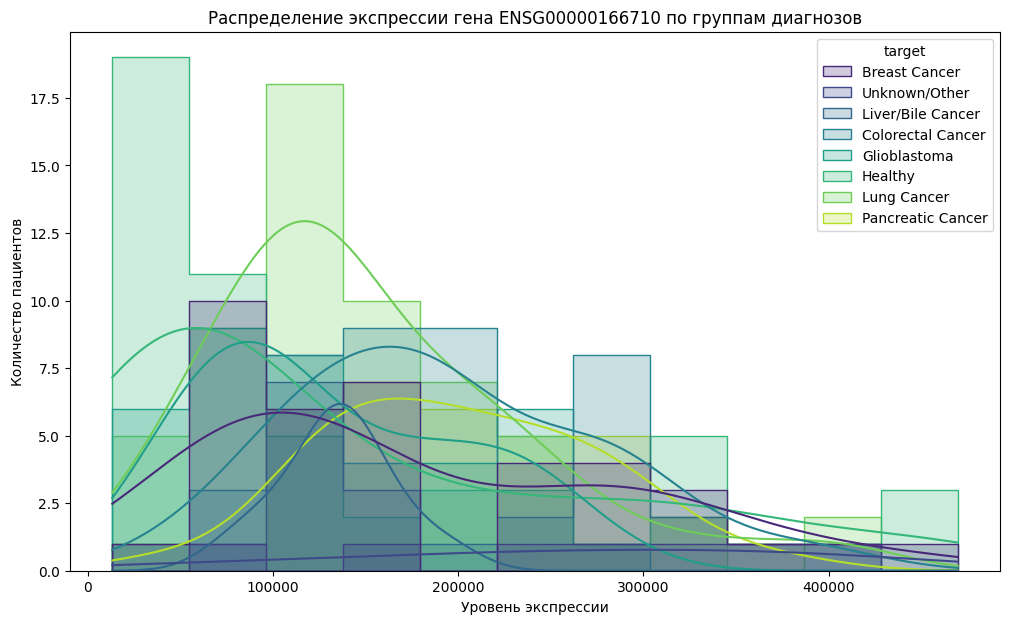

Index(['ENSG00000166710', 'ENSG00000163736', 'ENSG00000244734',
       'ENSG00000205542', 'ENSG00000075624'],
      dtype='object', name='Unnamed: 0')


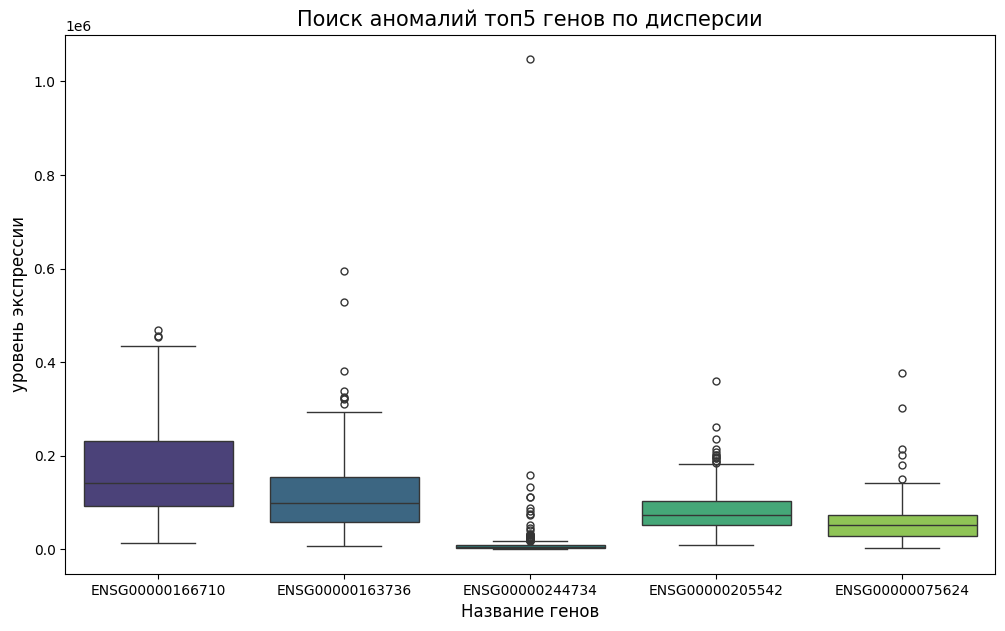

In [6]:
# --- E) Визуализация ---

## 1. меня заинтересовал ген ENSG00000166710 своей большой дисперсией, поэтому посмотрим по графику, действительно его высокий уровень экспрессии влияет на наличие заболеваний
#создаем сетку
plt.figure(figsize= (12, 7))
#выбираем этот ген
target_gen = df_gen.loc[: , 'ENSG00000166710']
display(target_gen)

#Создаем наш график
sns.histplot(
    data = df_gen,
    x = target_gen,
    hue= 'target', #разделение цветов в зависимости от колонки таргет
    kde = True, #добавляет плавную линию поверх столбиков
    palette= 'viridis', #использует готовую палитру цветов
    element= 'step', #добавляет контуры для колонок для четкости
)

plt.title('Распределение экспрессии гена ENSG00000166710 по группам диагнозов')
plt.xlabel('Уровень экспрессии')
plt.ylabel('Количество пациентов')

plt.show()
#по графику видно что у большинства здоровых людей этот ген малоактивный, а у больных имеет высокую экспрессию (например у большинства больных раком легких экспрессия этого гена приблизительно 10000-15000

## 2. Поиск  аномальных генов
#возьмем первые 5 генов по вариабельности для наглядности
target_genes2 = df_gen.iloc[:, :5].columns
print(target_genes2)

#создаем сетку
plt.figure(figsize=(12, 7))

# создаем boxplot
sns.boxplot(
    data = df_gen[target_genes2],
    palette = 'viridis',
    fliersize= 5 #размер точек
)

plt.title('Поиск аномалий топ5 генов по дисперсии', fontsize = 15)
plt.xlabel('Название генов', fontsize = 12)
plt.ylabel('уровень экспрессии', fontsize = 12)

plt.show()
#чем ниже сам боксплот тем менее активный ген 
# круглые точки показывают аномальные случаи экспресси этого гена

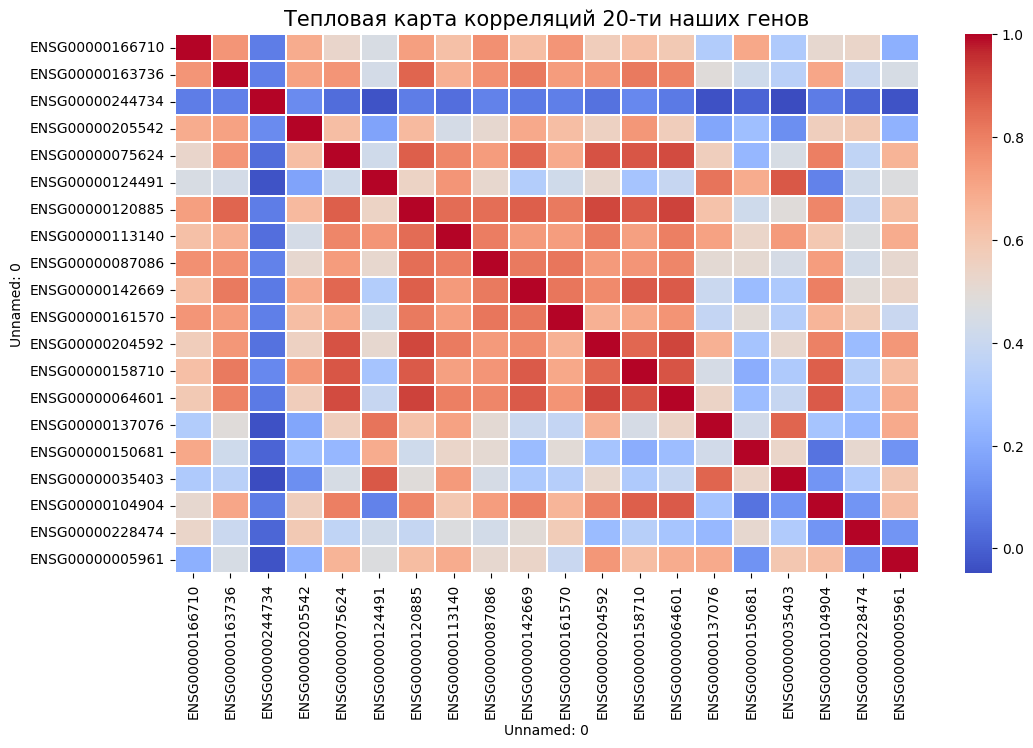

In [8]:
## 3. Тепловая карта. посмотрим на то, как связаны гены друг с другом
# берем 20 генов по дисперсии
top_20genes = df_gen.iloc[:, :20].columns

# считаем корреляцию этих генов
corr = df_gen[top_20genes].corr()

#создаем сетку
plt.figure(figsize= (12,7))
#создаем нашу тепловую карту
sns.heatmap(
    data= corr,
    annot = False, #отключение подписей цифр
    cmap= 'coolwarm', #переливание цветов
    linewidths= 0.3 #создает белые линии на границах квадратов для наглядности
)
plt.title('Тепловая карта корреляций 20-ти наших генов', fontsize=15)
plt.show()

# чем более красный квадратик, тем больше гены связаны друг с другом

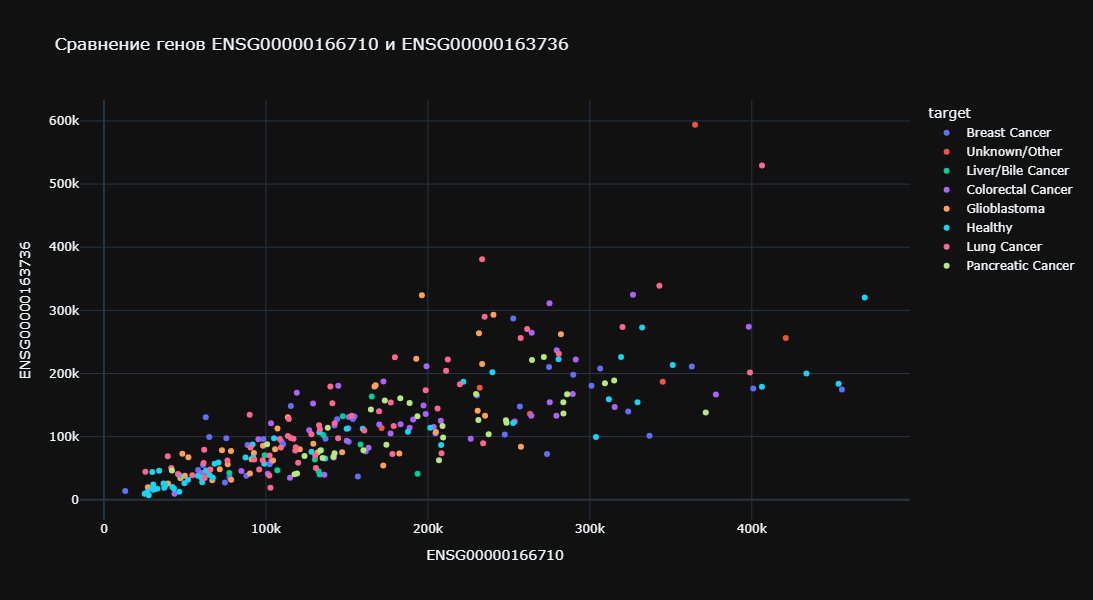

In [29]:
# составляем интерактивную карту рассеивания по двум генам, где, если навести на точку курсор покажется индекс пациента ( Scatter Plot)

px.scatter(
    data_frame = df_gen,
    x = df_gen.columns[0],
    y = df_gen.columns[1],
    color= 'target',
    width = 900,
    height = 600,
    title= f"Сравнение генов {df_gen.columns[0]} и {df_gen.columns[1]}",
    template='plotly_dark',
    opacity= 1 #Прозрачность строчек
)

# точки схоже идут по диагонали вверх, что в теории может указывать на их взаимосвязь (ко-экспрессированы)
# типы рака перекрывают друг друга, следовательно только по этим двум генам практически невозможно идентифицировать болезнь, здоровые гены также не выделены в отдельный кластер
# с увеличением экспрессии увеличечивается дисперсия этих генов  
# есть несколько ыбросов с высокими значениями экспрессии генов


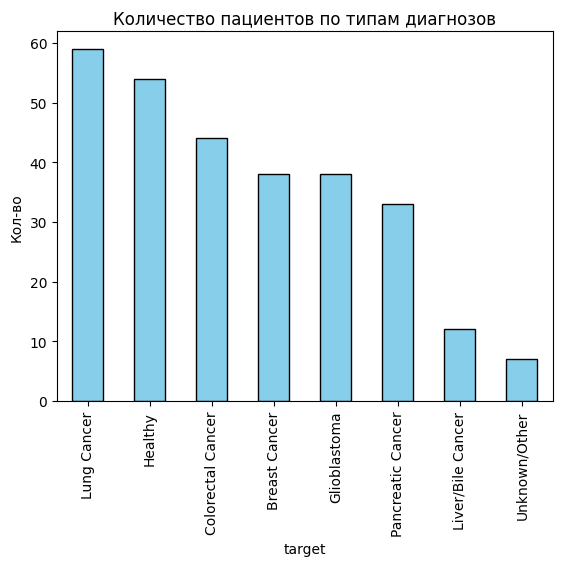

In [33]:
# Barplot для к-ва наших пациентов
df_gen['target'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Количество пациентов по типам диагнозов')
plt.ylabel('Кол-во')
plt.show()
